<a href="https://colab.research.google.com/github/raj-aryan7/ProteinBERT/blob/main/notebooks/LSTM_without_pretraining_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install tape-proteins
!pip install biopython
!pip install torch torchvision
!pip install pandas numpy scikit-learn tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.2/301.2 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.1 MB/s eta 0:00:00


In [4]:
!pip install lmdb

In [5]:
!wget https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
!tar -xzf secondary_structure.tar.gz
!mkdir data
!mv secondary_structure data/

--2026-03-16 16:52:39--  https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.125.232, 16.15.201.38, 52.217.196.136, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.125.232|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 251794897 (240M) [application/x-tar]
Saving to: ‘secondary_structure.tar.gz’

secondary_structure 100%[===================>] 240.13M  36.6MB/s    in 6.7s    

2026-03-16 16:52:47 (35.6 MB/s) - ‘secondary_structure.tar.gz’ saved [251794897/251794897]



In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

from tape.datasets import SecondaryStructureDataset
from tape import TAPETokenizer

from tqdm import tqdm

In [7]:
!ls data/secondary_structure

secondary_structure_casp12.lmdb  secondary_structure_ts115.lmdb
secondary_structure_cb513.lmdb	 secondary_structure_valid.lmdb
secondary_structure_train.lmdb


In [8]:
train_dataset = SecondaryStructureDataset(
    data_path='./data',
    split='train'
)

valid_dataset = SecondaryStructureDataset(
    data_path='./data',
    split='valid'
)

print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))

Train size: 8678
Valid size: 2170


In [9]:
tokenizer = TAPETokenizer(vocab='iupac')

In [10]:
def collate_fn(batch):

    input_ids = [torch.tensor(item[0]) for item in batch]
    labels = [torch.tensor(item[2]) for item in batch]

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
    labels = pad_sequence(labels, batch_first=True, padding_value=-1)

    return input_ids, labels

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [12]:
class LSTMModel(nn.Module):

    def __init__(self, vocab_size=30, embed_dim=128, hidden_dim=256, num_classes=3):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, x):

        x = self.embedding(x)

        x, _ = self.lstm(x)

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel().to(device)

criterion = nn.CrossEntropyLoss(ignore_index=-1)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [14]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [15]:
epochs = 20

for epoch in range(epochs):

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader):

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(
            outputs.view(-1,3),
            labels.view(-1)
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=-1)

        mask = labels != -1

        correct += (preds[mask] == labels[mask]).sum().item()
        total += mask.sum().item()

    train_accuracy = correct / total
    train_loss = train_loss / len(train_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    #VALIDATION

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in valid_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(
                outputs.view(-1,3),
                labels.view(-1)
            )

            val_loss += loss.item()

            preds = outputs.argmax(dim=-1)

            mask = labels != -1

            correct += (preds[mask] == labels[mask]).sum().item()
            total += mask.sum().item()

    val_accuracy = correct / total
    val_loss = val_loss / len(valid_loader)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

100%|██████████| 543/543 [00:23<00:00, 22.84it/s]



Epoch 1/20
Train Loss: 0.7704 | Train Acc: 0.6586
Val Loss: 0.7001 | Val Acc: 0.6977


100%|██████████| 543/543 [00:22<00:00, 23.85it/s]



Epoch 2/20
Train Loss: 0.7076 | Train Acc: 0.6929
Val Loss: 0.6874 | Val Acc: 0.7033


100%|██████████| 543/543 [00:22<00:00, 24.04it/s]


...


Epoch 18/20
Train Loss: 0.5288 | Train Acc: 0.7761
Val Loss: 0.7272 | Val Acc: 0.6998


100%|██████████| 543/543 [00:23<00:00, 23.34it/s]



Epoch 19/20
Train Loss: 0.5278 | Train Acc: 0.7768
Val Loss: 0.7336 | Val Acc: 0.6963


100%|██████████| 543/543 [00:23<00:00, 23.47it/s]



Epoch 20/20
Train Loss: 0.5119 | Train Acc: 0.7840
Val Loss: 0.7428 | Val Acc: 0.6962


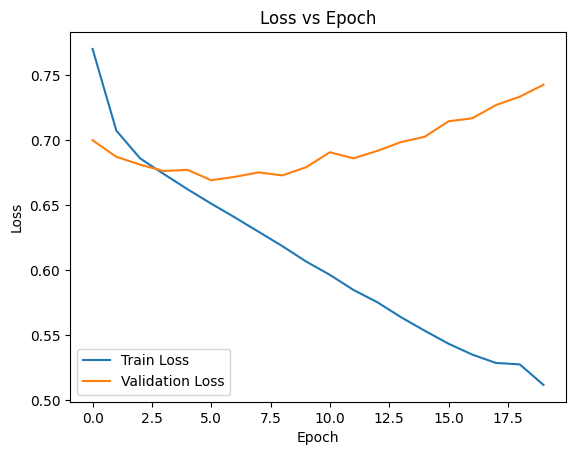

In [16]:
plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.title("Loss vs Epoch")

plt.show()

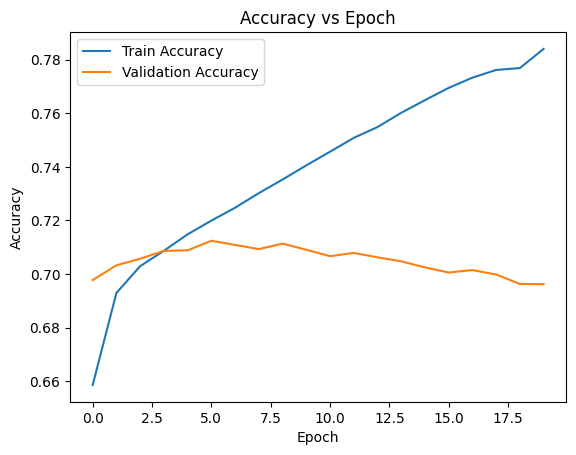

In [18]:
plt.figure()

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Accuracy vs Epoch")

plt.show()

In [19]:
test_dataset = SecondaryStructureDataset(
    data_path='./data',
    split='cb513'
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [20]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        loss = criterion(
            outputs.view(-1,3),
            labels.view(-1)
        )

        test_loss += loss.item()

        preds = outputs.argmax(dim=-1)

        mask = labels != -1

        correct += (preds[mask] == labels[mask]).sum().item()
        total += mask.sum().item()

test_accuracy = correct / total
test_loss = test_loss / len(test_loader)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.7778663544943838
Test Accuracy: 0.6818647824882239


In [21]:
torch.save(model.state_dict(), "lstm_without_pretraining.pt")

In [22]:
print("Experiment: LSTM without pretraining")
print("Train samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))
print("Epochs:", epochs)

print("Final Validation Accuracy:", val_accuracies[-1])
print("Test Accuracy:", test_accuracy)

Experiment: LSTM without pretraining
Train samples: 8678
Validation samples: 2170
Epochs: 20
Final Validation Accuracy: 0.6962065318684002
Test Accuracy: 0.6818647824882239


In [23]:
EPOCHS_TO_SHOW = 5

train_losses_5 = train_losses[:EPOCHS_TO_SHOW]
val_losses_5 = val_losses[:EPOCHS_TO_SHOW]

train_acc_5 = train_accuracies[:EPOCHS_TO_SHOW]
val_acc_5 = val_accuracies[:EPOCHS_TO_SHOW]

epochs_range = range(1, EPOCHS_TO_SHOW + 1)

In [24]:
print("Results for first 5 epochs\n")

for i in range(EPOCHS_TO_SHOW):

    print(f"Epoch {i+1}")

    print("Train Loss:", train_losses_5[i])
    print("Train Accuracy:", train_acc_5[i])

    print("Validation Loss:", val_losses_5[i])
    print("Validation Accuracy:", val_acc_5[i])

    print("-"*40)

Results for first 5 epochs

Epoch 1
Train Loss: 0.770359909446639
Train Accuracy: 0.6586020210604783
Validation Loss: 0.7001292245352969
Validation Accuracy: 0.6977112065947129
----------------------------------------
Epoch 2
Train Loss: 0.7075936063218512
Train Accuracy: 0.6929327704121572
Validation Loss: 0.6874101376708817
Validation Accuracy: 0.7032504924308397
----------------------------------------
Epoch 3
Train Loss: 0.6862295255696137
Train Accuracy: 0.7029214852800374
Validation Loss: 0.6813381621066261
Validation Accuracy: 0.7057032199680032
----------------------------------------
Epoch 4
Train Loss: 0.6741603061858681
Train Accuracy: 0.708651829591354
Validation Loss: 0.6764527489157284
Validation Accuracy: 0.7086138139194981
----------------------------------------
Epoch 5
Train Loss: 0.6624469234578957
Train Accuracy: 0.7148134126968765
Validation Loss: 0.6773565486073494
Validation Accuracy: 0.7088346671311168
----------------------------------------


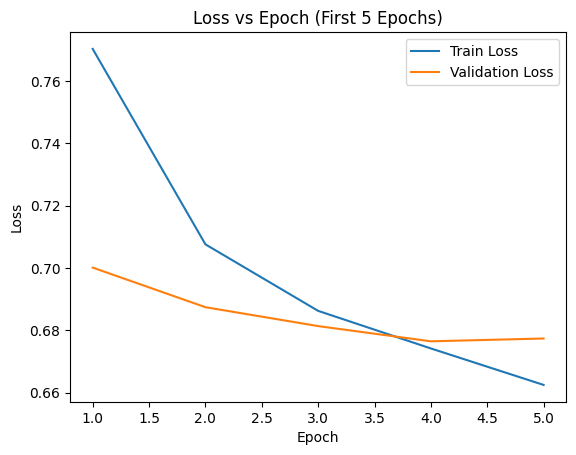

In [25]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(epochs_range, train_losses_5, label="Train Loss")
plt.plot(epochs_range, val_losses_5, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss vs Epoch (First 5 Epochs)")

plt.legend()

plt.show()

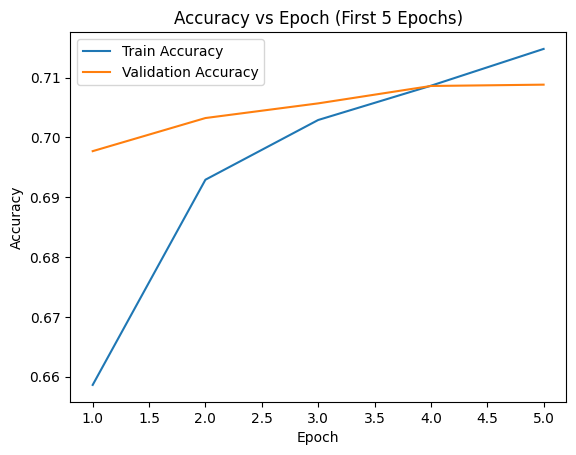

In [26]:
plt.figure()

plt.plot(epochs_range, train_acc_5, label="Train Accuracy")
plt.plot(epochs_range, val_acc_5, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch (First 5 Epochs)")

plt.legend()

plt.show()

In [27]:
print("Summary for Epoch = 5")

print("Final Train Loss:", train_losses_5[-1])
print("Final Train Accuracy:", train_acc_5[-1])

print("Final Validation Loss:", val_losses_5[-1])
print("Final Validation Accuracy:", val_acc_5[-1])

Summary for Epoch = 5
Final Train Loss: 0.6624469234578957
Final Train Accuracy: 0.7148134126968765
Final Validation Loss: 0.6773565486073494
Final Validation Accuracy: 0.7088346671311168
